In [30]:
# import 
from bs4 import BeautifulSoup
import requests, re
import pandas as pd

# Define Default Parameters
parameters = {'in_di': 1, 'in_zen': 60,'in_atm': 1,
             'in_rds': 100,
             'in_dz': 2, 'in_rho': 350, 
             'in_albv': 0, 'in_albn': 0.4,
             'in_bc1': 0, 'in_mac_scl': 1.0, 'in_bc2': 0, 
             'in_dst1': 0, 'in_dst2': 0,'in_dst3': 0, 'in_dst4': 0,
             'in_volc': 0, 'in_exp1': 0}

# Create function to generate lookup table
def generate_lookup_table(parameters, size):
    # Make Request
    url ="http://snow.engin.umich.edu"
    url2 = url + '/process.php'
    response = requests.post(url2, data=parameters)
    # Extract Output
    soup = BeautifulSoup(response.content, 'html.parser')
    results = soup.find(href= True).get('href')
    output = url + '/' + results
    df = pd.read_csv(output, header= None, sep='\s+', names=['lambda',str(size)])
    return(df)

# Generate lookup table for varying grain size
df_ls = []
#grain_list = range(30,1502,2)
grain_list = range(30,1501,1) #subsample
for grain_size in grain_list:
    parameters['in_rds'] = grain_size
    newdf = generate_lookup_table(parameters, grain_size)
    if grain_size == 30:
        df_ls.append(newdf)
    else:
        df_ls.append(newdf.iloc[:,1])
    
# Create final table
grain_tbl = pd.concat(df_ls, axis=1, ignore_index=True) # Add column names from grain list
grain_tbl.columns = ['lambda'] + list(map(str, list(grain_list)))
grain_tbl.head(5)



,lambda,30,31,32,33,34,35,36,37,38,...,1491,1492,1493,1494,1495,1496,1497,1498,1499,1500
0,0.305,0.981723,0.981419,0.981151,0.980829,0.980585,0.980287,0.979865,0.979689,0.979388,...,0.877439,0.877397,0.877372,0.877322,0.877289,0.877248,0.877215,0.877174,0.877134,0.877099
1,0.315,0.983334,0.982908,0.982694,0.982337,0.982015,0.981754,0.981357,0.981034,0.980614,...,0.887882,0.887847,0.887807,0.887781,0.887751,0.887717,0.887689,0.887642,0.887607,0.887569
2,0.325,0.984340,0.983967,0.983757,0.983587,0.983356,0.983070,0.982947,0.982721,0.982444,...,0.894962,0.894950,0.894912,0.894883,0.894853,0.894810,0.894785,0.894743,0.894723,0.894684
3,0.335,0.985177,0.984847,0.984614,0.984367,0.984136,0.983989,0.983669,0.983465,0.983247,...,0.898817,0.898783,0.898754,0.898711,0.898690,0.898658,0.898617,0.898586,0.898554,0.898534
4,0.345,0.986244,0.985975,0.985778,0.985618,0.985300,0.985119,0.984790,0.984710,0.984480,...,0.905808,0.905773,0.905760,0.905716,0.905680,0.905658,0.905633,0.905599,0.905564,0.905542


In [31]:
# save to csv
file_name = "Results/LookupTable2.csv"
grain_tbl.to_csv(file_name,sep=',')
print('saved!')

saved!


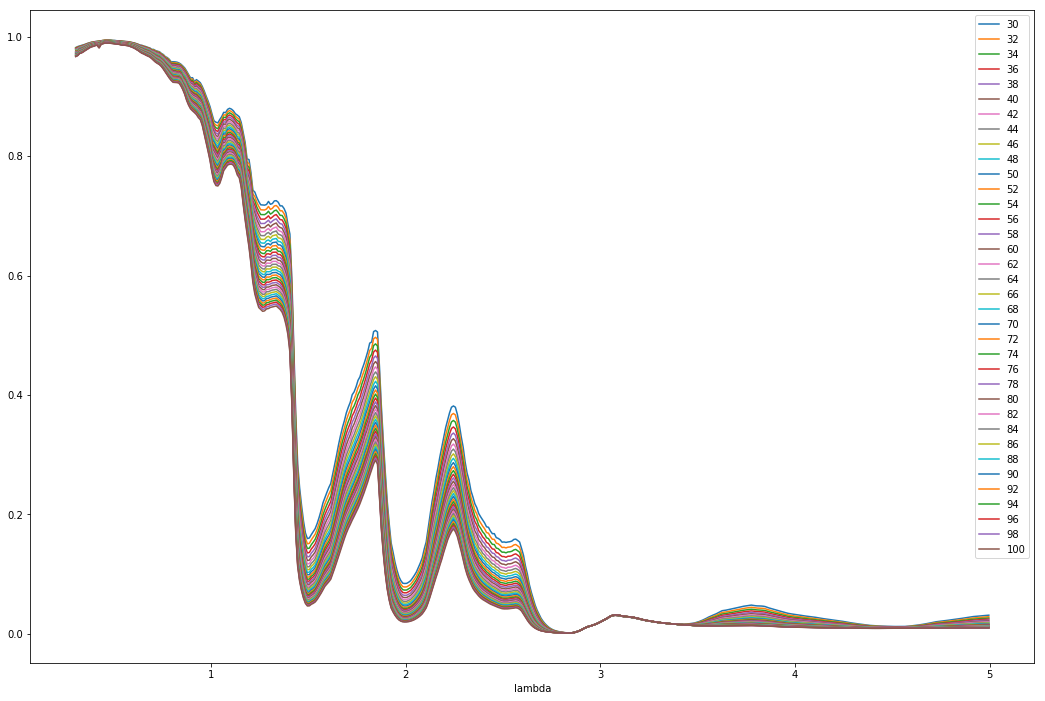

In [22]:
grain_tbl.plot(x="lambda", kind="line",figsize=(18,12))